In [1]:
# analysis specific imports
import spacenet as sn

# general imports
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
from scipy.spatial import KDTree
from scipy.stats import mannwhitneyu

np.random.seed(0)   
plt.rcParams['figure.dpi'] = 200


netPCF_kwargs_3d = dict(spatial_kernel_bandwidth=45,
                    spatial_kernel_n=2,
                    r_min=0, 
                    r_max=300, 
                    r_step=10,
                    edge_weight_name='Distance', 
                    return_confidence_interval=True,
                    low_memory=False,
                    verbose=True,
                    n_jobs=-1) 

netPCF_kwargs_2d = dict(spatial_kernel_bandwidth=45,
                    spatial_kernel_n=2,
                    r_min=0, 
                    r_max=300, 
                    r_step=10,
                    edge_weight_name='Distance', 
                    return_confidence_interval=True,
                    low_memory=False,
                    verbose=False,
                    n_jobs=1) 

scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=1,marker_size=15,add_legend=False,edge_weight_name='Distance',scatter_kwargs=scatter_kwargs) 
scalebar_kwargs = dict(size=200, label='',loc='lower right',pad = 1.5,frameon=False,size_vertical=10,zorder=1000)
network_kwargs = dict(network_type='Delaunay',min_edge_distance=0,max_edge_distance=40)

In [2]:
# import the data
data = pd.read_csv('../data/imc_breast_carcinoma_kuett_2022/cell_pointcloud_main_HER2.csv')

points = data[['x', 'y', 'z']].to_numpy()   
labels = data['annotation'].to_numpy()   
unique_labels = np.unique(labels)
unique_annotations_colors = {ann: plt.cm.tab10(i % 10) for i, ann in enumerate(unique_labels)}

# scale the points to microns [1,1,2]µm
points[:,2]=2*points[:,2]

print(unique_labels)

#Clean the data by removing points within 10µm of the bounding cuboid
bounding_box_min = np.min(points, axis=0) + 10
bounding_box_max = np.max(points, axis=0) - 10

# Create a mask for points outside the bounding box
mask = np.all((points >= bounding_box_min) & (points <= bounding_box_max), axis=1)

# Filter points and labels
points = points[mask]
labels = labels[mask]

# move other labels not of interest into the stromal group
labels[labels=='Stomal/Other'] = 'Stromal (unassigned)'
labels[labels=='Macrophages'] = 'Stromal (unassigned)'

# make a colormap
epi_color=plt.cm.tab10(7)
epi_color = (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 0.5)

label_colors = {'B cells':plt.cm.tab10(2),
                'CD8+ T cells':plt.cm.tab10(4),
                'CD8- T cells':plt.cm.tab10(5),
                'Endothelial cells':plt.cm.tab10(3),
                'Epithelial':epi_color,
                'Stromal (unassigned)':plt.cm.tab10(9)}

# Convert labels to numeric values
label_mapping = {label: idx for idx, label in enumerate(np.unique(labels))}
numeric_labels = np.array([label_mapping[label] for label in labels])
color_list = [label_colors[i] for i in labels]

['B cells' 'CD8+ T cells' 'CD8- T cells' 'Endothelial cells' 'Epithelial'
 'Macrophages' 'Stomal/Other']


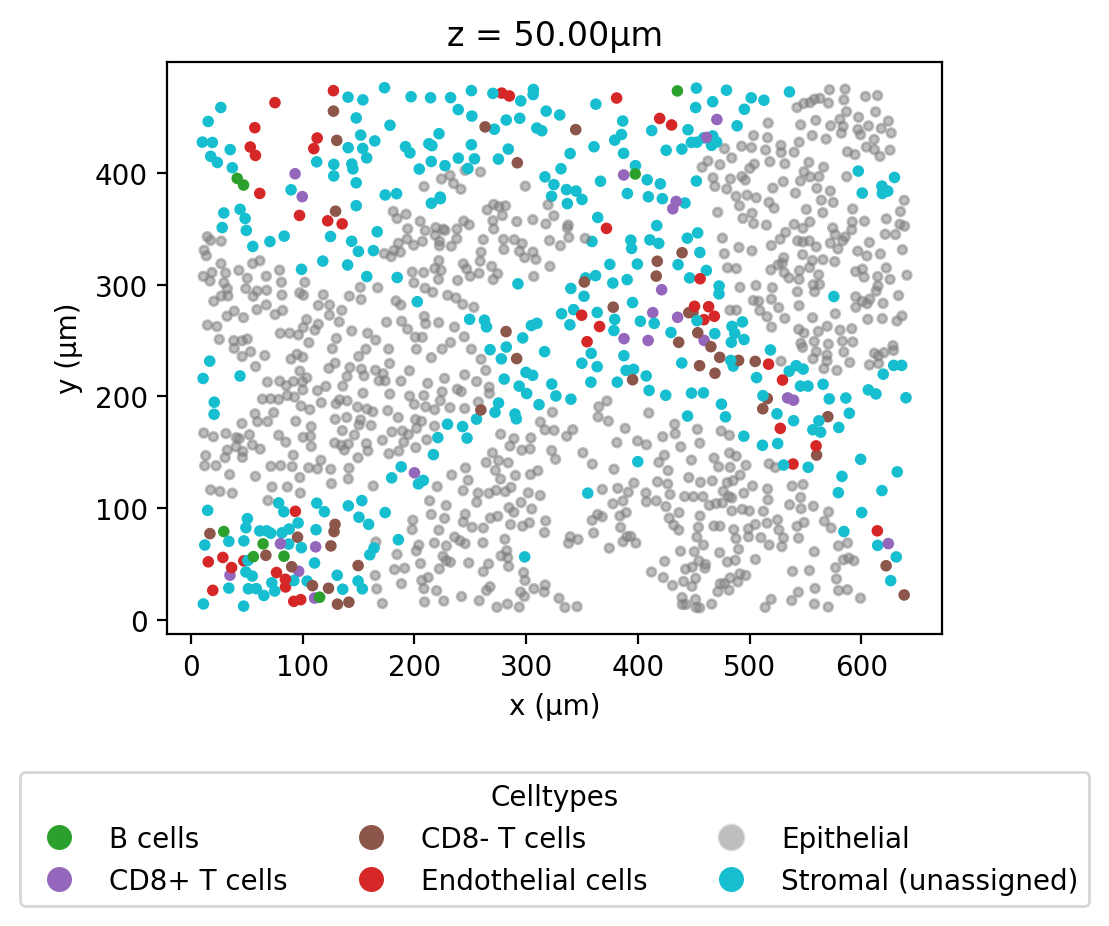

In [5]:
# plot a 2d slice
this_z = 50
z_distance_indicies = np.logical_and(points[:,2] >= this_z, points[:,2] <= this_z+4)

this_color_list = [label_colors[i] for i in labels[z_distance_indicies]]

fig,ax = plt.subplots(figsize=(5,5))
ax.scatter(points[z_distance_indicies,0], points[z_distance_indicies,1], c=this_color_list, s=10)  
ax.set_aspect('equal')
ax.set_title(f'z = {this_z:.2f}µm')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')

handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, 
                       markerfacecolor=label_colors[label], markersize=10) 
           for label in label_mapping.keys()]

ax.legend(handles=handles, title='Celltypes', bbox_to_anchor=(0.5, -0.5), loc='lower center',ncol=3)


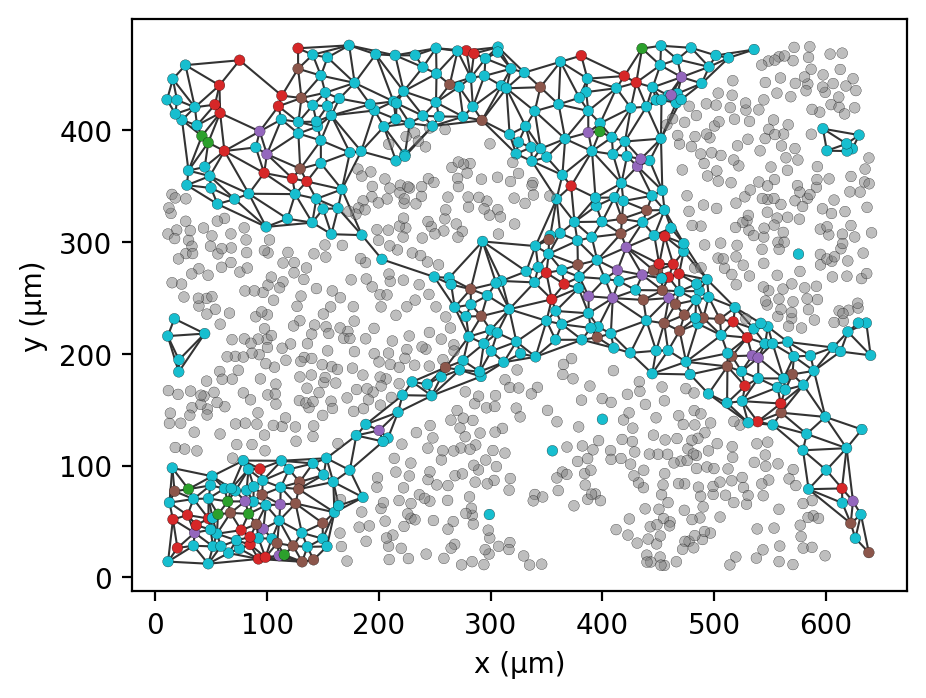

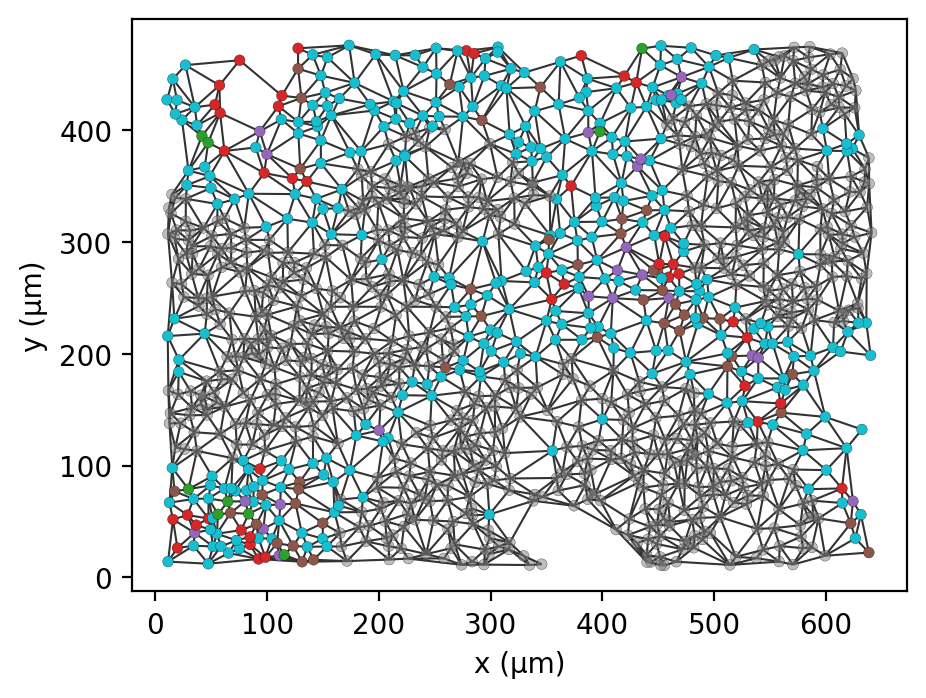

In [6]:
scatter_kwargs=dict(linewidths=0.1,edgecolors='black')

this_z_rep=50
z_distance_indicies = np.logical_and(points[:,2] >= this_z_rep, points[:,2] <= this_z_rep+4)
z_stromal_mask = np.logical_and(labels != 'Epithelial', z_distance_indicies)
this_color_list = [label_colors[i] for i in labels[z_distance_indicies]]


fig,ax = plt.subplots(figsize=(5,5))

plot_g = sn.utils.spatial_network_from_points(points[z_stromal_mask,:2],max_edge_distance=50)
sn.utils.plot_spatial_network(plot_g,edge_weight_name=None, ax=ax,marker_size=0,edge_width=0.75)
ax.scatter(points[z_distance_indicies,0], points[z_distance_indicies,1], c=this_color_list,s=15,**scatter_kwargs)      
ax.set_aspect('equal')
#ax.set_title(f'z = {this_z_rep:.0f}µm')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_axis_on()
#fig.savefig(f'{path_to_save_figs}/pointclouds/pointcloud_TME_z{this_z_rep:.0f}.png',bbox_inches='tight',dpi=300)

fig,ax = plt.subplots(figsize=(5,5))

plot_g = sn.utils.spatial_network_from_points(points[z_distance_indicies,:2],max_edge_distance=50)
sn.utils.plot_spatial_network(plot_g,edge_weight_name=None, ax=ax,marker_size=0,edge_width=0.75)   
ax.scatter(points[z_distance_indicies,0], points[z_distance_indicies,1], c=this_color_list,s=15,**scatter_kwargs)  
ax.set_aspect('equal')
#ax.set_title(f'z = {this_z_rep:.2f}µm')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_axis_on()
#fig.savefig(f'{path_to_save_figs}/pointclouds/pointcloud_FULL_z{this_z_rep:.0f}.png',bbox_inches='tight',dpi=300)




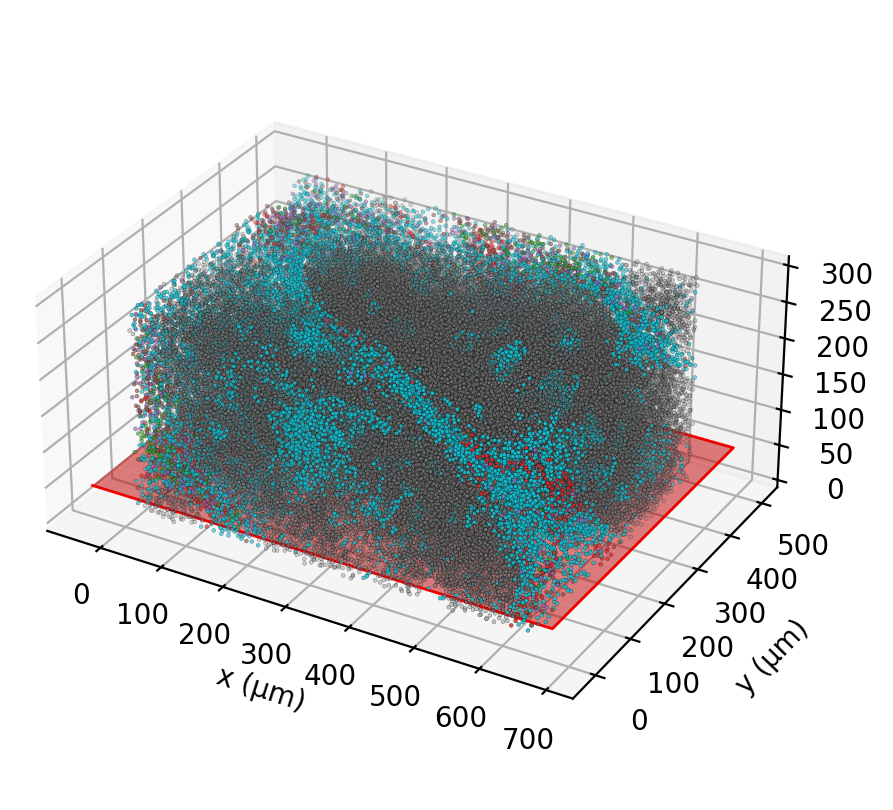

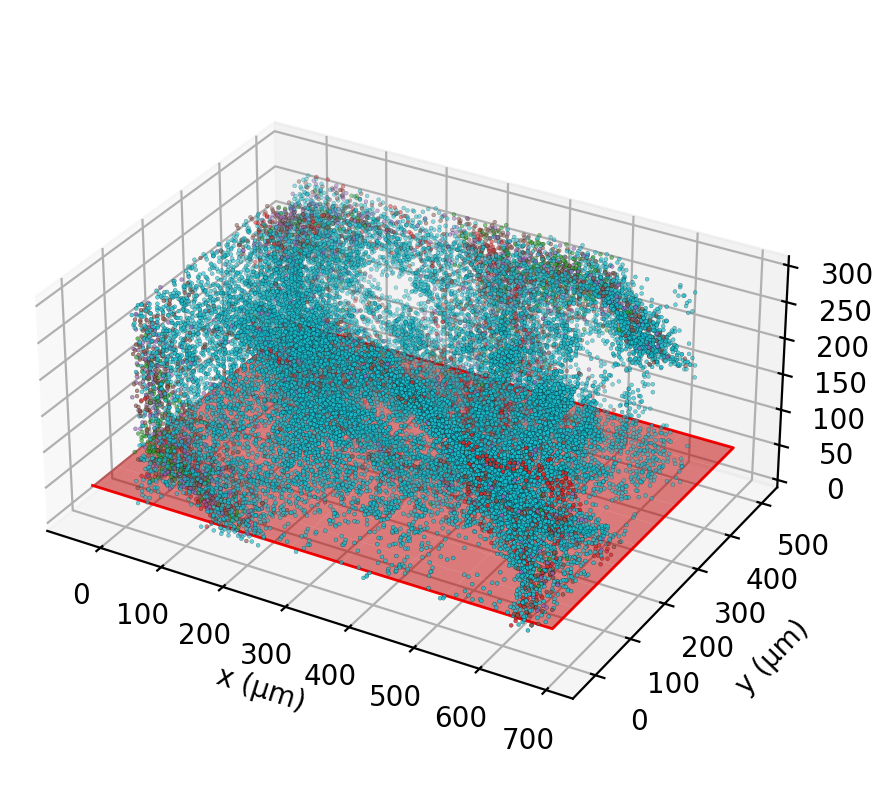

In [10]:
%matplotlib inline
plt.close('all')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 5))

ax.scatter(points[:,0], points[:,1],points[:,2],c=color_list, s=2,**scatter_kwargs)  
ax.set_aspect('equal')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_zlabel('z (µm)')

# BEGIN: Add a rectangular plane at z = 50
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 10), np.linspace(ylim[0], ylim[1], 10))
zz = np.full(xx.shape, this_z_rep)

ax.plot_surface(xx, yy, zz, color='red', alpha=0.5, linewidth=1)  # Adjust color and transparency as needed
ax.plot([xlim[0],xlim[1],xlim[1],xlim[0]],[ylim[0],ylim[0],ylim[1],ylim[1]],[this_z_rep,this_z_rep,this_z_rep,this_z_rep],color='red',linewidth=1)  # Draw the edges of the rectangle
# END: Add a rectangular plane at z = 50

#ax.set_box_aspect([1,1,0.5],zoom=0.85)  # Set aspect ratio to prevent zlabel from being cut off
fig.subplots_adjust(right=0.85)   # give the 3D axes more room
#fig.savefig(
#    f'{path_to_save_figs}/pointclouds/pointcloud_3d_Full.png',
#    dpi=300,
#    bbox_inches=None,             # often better for 3D
#    pad_inches=0.1
#)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 5))

mask = labels != 'Epithelial'
#mask = np.logical_and(mask, labels != 'Stromal (unassigned)')
ax.scatter(points[mask,0], points[mask,1],points[mask,2],c=np.array(color_list)[mask], s=2,**scatter_kwargs)  
ax.set_aspect('equal')
ax.set_xlabel('x (µm)',)
ax.set_ylabel('y (µm)')
ax.set_zlabel('z (µm)')

ax.plot_surface(xx, yy, zz, color='red', alpha=0.5,linewidth=1) 
ax.plot([xlim[0],xlim[1],xlim[1],xlim[0]],[ylim[0],ylim[0],ylim[1],ylim[1]],[this_z_rep,this_z_rep,this_z_rep,this_z_rep],color='red',linewidth=1)  # Draw the edges of the rectangle
#ax[1].set_box_aspect('equal', zoom=0.85)
fig.subplots_adjust(right=0.85)   # give the 3D axes more room
#fig.savefig(
#    f'{path_to_save_figs}/pointclouds/pointcloud_3d_TME.png',
#    dpi=300,
#    bbox_inches=None,             # often better for 3D
#    pad_inches=0.1
#)

Text(0.5, 1.0, '2D: z = 50µm')

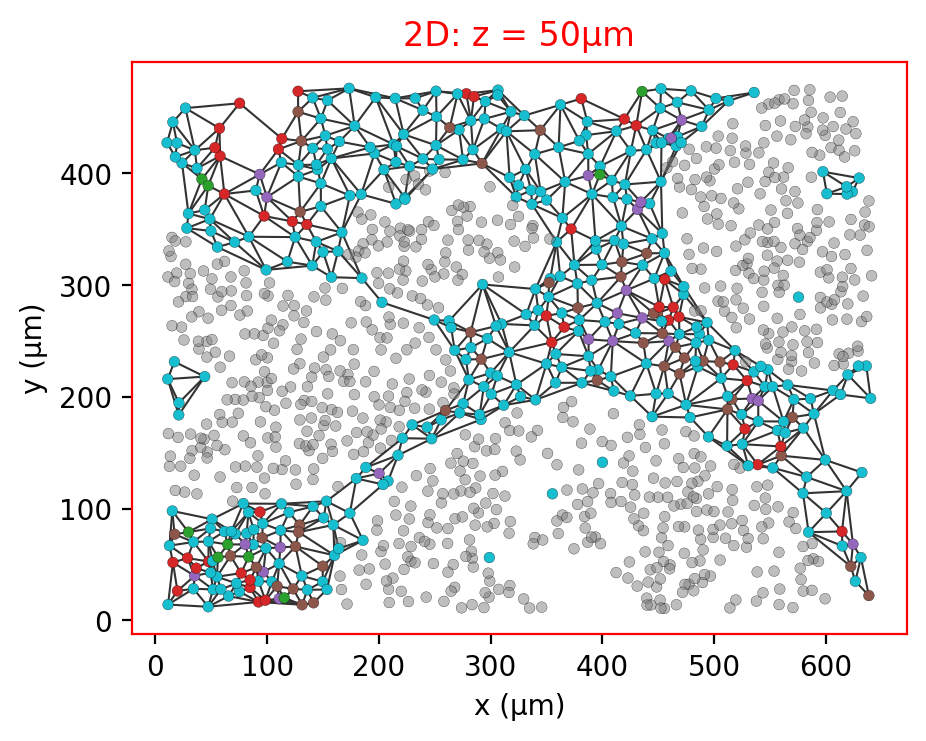

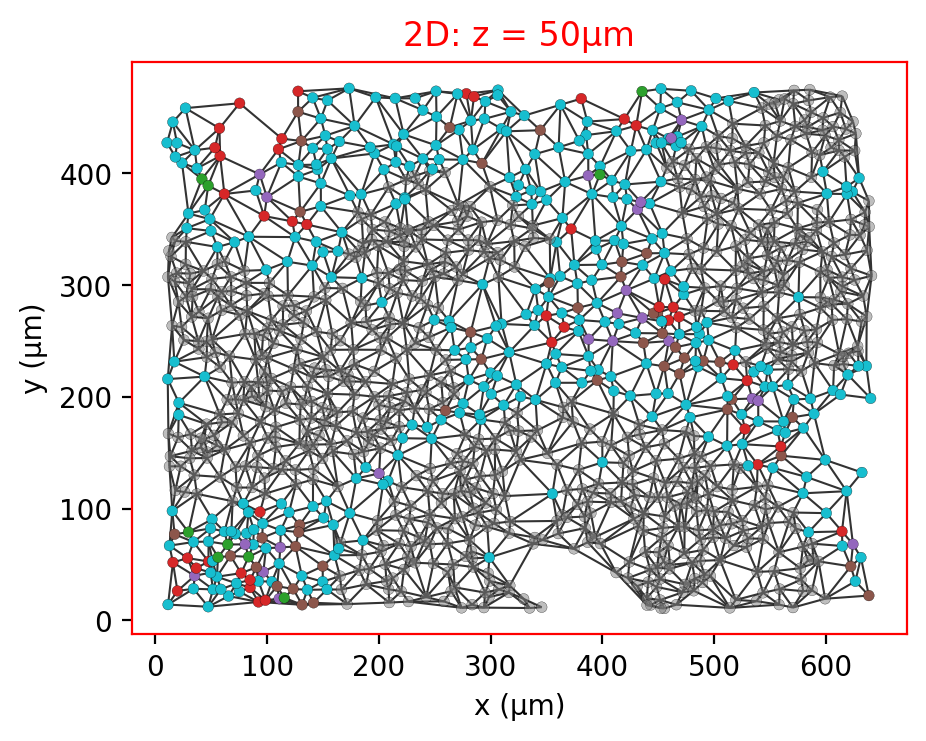

In [11]:
scatter_kwargs=dict(linewidths=0.1,edgecolors='black')

this_z_rep=50
z_distance_indicies = np.logical_and(points[:,2] >= this_z_rep, points[:,2] <= this_z_rep+4)
z_stromal_mask = np.logical_and(labels != 'Epithelial', z_distance_indicies)
this_color_list = [label_colors[i] for i in labels[z_distance_indicies]]


fig,ax = plt.subplots(figsize=(5,5))

plot_g = sn.utils.spatial_network_from_points(points[z_stromal_mask,:2],max_edge_distance=50)
sn.utils.plot_spatial_network(plot_g,edge_weight_name=None, ax=ax,marker_size=0,edge_width=0.75)
ax.scatter(points[z_distance_indicies,0], points[z_distance_indicies,1], c=this_color_list,s=15,**scatter_kwargs)      
ax.set_aspect('equal')
#ax.set_title(f'z = {this_z_rep:.0f}µm')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_axis_on()
ax.spines['top'].set_color('red')
ax.spines['bottom'].set_color('red')
ax.spines['left'].set_color('red')
ax.spines['right'].set_color('red')
ax.set_title(f'2D: z = {this_z_rep:.0f}µm',color='red')

#fig.savefig(f'{path_to_save_figs}/pointclouds/pointcloud_TME_z{this_z_rep:.0f}.png',bbox_inches='tight',dpi=300)

fig,ax = plt.subplots(figsize=(5,5))

plot_g = sn.utils.spatial_network_from_points(points[z_distance_indicies,:2],max_edge_distance=50)
sn.utils.plot_spatial_network(plot_g,edge_weight_name=None, ax=ax,marker_size=0,edge_width=0.75)   
ax.scatter(points[z_distance_indicies,0], points[z_distance_indicies,1], c=this_color_list,s=15,**scatter_kwargs)  
ax.set_aspect('equal')
#ax.set_title(f'z = {this_z_rep:.2f}µm')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_axis_on()
ax.spines['top'].set_color('red')
ax.spines['bottom'].set_color('red')
ax.spines['left'].set_color('red')
ax.spines['right'].set_color('red')
ax.set_title(f'2D: z = {this_z_rep:.0f}µm',color='red')
#fig.savefig(f'{path_to_save_figs}/pointclouds/pointcloud_FULL_z{this_z_rep:.0f}.png',bbox_inches='tight',dpi=300)




# Reproducing distance analysis

/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_86199/1682036065.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  this_ax.set_xticklabels(['2D slices', '3D'],rotation=45,ha='right')
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_86199/1682036065.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  this_ax.set_xticklabels(['2D slices', '3D'],rotation=45,ha='right')
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_86199/1682036065.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  this_ax.set_xticklabels(['2D slices', '3D'],rotation=45,ha='right')


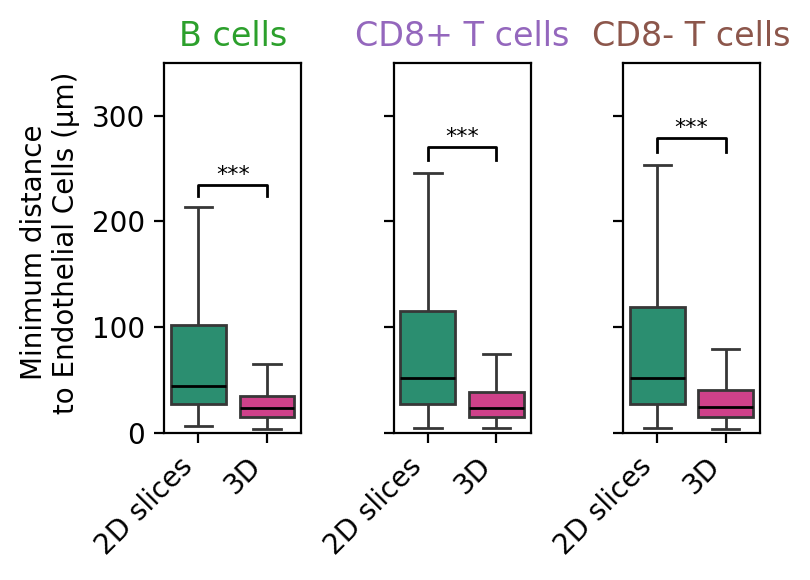

In [17]:


def upper_whisker(data):
    data = np.asarray(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    return data[data <= upper_bound].max()

twod_col=plt.cm.Dark2(0)
threed_col=plt.cm.Dark2(3)  

endo_points = points[labels == 'Endothelial cells']   
endo_tree = KDTree(endo_points) 

cell_types_of_interest = ['B cells', 'CD8+ T cells', 'CD8- T cells']    

z_slices = np.arange(10, 290, 4)
z_step = 4

fig,ax=plt.subplots(1,3,figsize=(4,3),sharex=True,sharey=True) 

for cell_idx,cell in enumerate(cell_types_of_interest):
    this_ax = ax.flatten()[cell_idx]
    # 3D analysis
    points_of_interest = points[labels == cell]   
    if cell == 'Endothelial cells':
        distances_to_endos, _ = endo_tree.query(points_of_interest,k=2)
        distances_to_endos = distances_to_endos[:,1]   
        print(distances_to_endos)
        print('here')
    else:
        distances_to_endos, _ = endo_tree.query(points_of_interest,k=1)
    
    
    # 2D slices
    all_distances_to_endos_2D = []
    for z in z_slices:
        z_distance_indicies = np.where(np.logical_and(points[:,2] >= z, points[:,2] <= z+z_step))[0]   
        points_in_slice = points[z_distance_indicies]
        labels_in_slice = labels[z_distance_indicies]
        endo_points_in_slice = points_in_slice[labels_in_slice == 'Endothelial cells']
        endo_tree_slice = KDTree(endo_points_in_slice)
        points_of_interest_in_slice = points_in_slice[labels_in_slice == cell]
        if cell == 'Endothelial cells':
            distances_to_endos_slice, _ = endo_tree_slice.query(points_of_interest_in_slice,k=2)
            distances_to_endos_slice = distances_to_endos_slice[:,1]
        else:   
            distances_to_endos_slice, _ = endo_tree_slice.query(points_of_interest_in_slice,k=1)
        all_distances_to_endos_2D.extend(distances_to_endos_slice)
        
        
    # Perform the Mann-Whitney U test
    stat, p_value = mannwhitneyu(all_distances_to_endos_2D, distances_to_endos)

    # --- significance label ---
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:    
        significance = 'ns'

    # --- compute whisker-based height ---
    uw_control = upper_whisker(all_distances_to_endos_2D)
    uw_nn = upper_whisker(distances_to_endos)
    y = max(uw_control, uw_nn)

    # small offsets for the bar + text
    h = (y * 0.05) if y != 0 else 1
    y_bar = y + h

    # --- draw significance bar ---
    x1, x2 = 0, 1
    this_ax.plot([x1, x1, x2, x2], [y_bar, y_bar + h, y_bar + h, y_bar], lw=1, c='black')
    this_ax.text((x1 + x2) / 2, y_bar + h, significance, ha='center', va='bottom', fontsize=8)

    
    
    
    sns.boxplot(data=[all_distances_to_endos_2D, distances_to_endos], 
                 ax=this_ax, 
                 palette=[twod_col, threed_col], 
                 medianprops=dict(color='black'),
                 showfliers=False)  

    this_ax.set_ylabel('Minimum distance \n to Endothelial Cells (µm)')
    #this_ax.set_ylabel('Density')
    this_ax.set_ylim(0, 350) 
    this_ax.set_title(f'{cell}',color=label_colors[cell])
    this_ax.set_xticklabels(['2D slices', '3D'],rotation=45,ha='right')  
plt.tight_layout()
handles = [plt.Line2D([0], [0], color=twod_col, lw=2, label='2D slices'),
           plt.Line2D([0], [0], color=threed_col, lw=2, label='3D')]

#ax[0, 0].legend(handles=handles, ncol=2, loc='upper center', bbox_to_anchor=(1.25, 1.5))
#fig.savefig(f'{path_to_save_figs}/distance_comps/distance_to_endothelial_comparison_box.png',bbox_inches='tight',dpi=300)

## Runnning 2d vs 3d vs 3D stromal

In [19]:
cells_of_interest = ['B cells', 'CD8+ T cells', 'CD8- T cells', 'Endothelial cells', 'Macrophages']
pairwise_combinations=[('Endothelial cells','Endothelial cells'),('Endothelial cells','B cells'),('Endothelial cells','CD8+ T cells'),('Endothelial cells','CD8- T cells')]

# precompute stroma network - will be the sample for all stroma interactions
stroma_indicies = np.where(np.isin(labels, ['B cells', 'CD8+ T cells', 'CD8- T cells', 'Endothelial cells', 'Macrophages', 'Stromal (unassigned)']))[0]
stromal_points = points[stroma_indicies,:]
stromal_labels = labels[stroma_indicies]

# generate the networks
G_stromal_3D = sn.utils.spatial_network_from_points(stromal_points,**network_kwargs)
G_all_3D = sn.utils.spatial_network_from_points(points,**network_kwargs)

stromal_nodes = np.array(G_stromal_3D.nodes())
all_nodes = np.array(G_all_3D.nodes())

In [20]:
# will require a significant amount of memmory
run_csr_check=False
if run_csr_check:
    dict_of_results_csr_check = {}
    this_r_all,this_g_all,CI_all = sn.pcf.cross_pair_correlation_function(G_all_3D,
                                                                    **netPCF_kwargs_3d) 

    dict_of_results_csr_check['all_3D']={'r':this_r_all,'g':this_g_all,'CI':CI_all}


    this_r_stromal,this_g_stromal,CI_stromal = sn.pcf.cross_pair_correlation_function(G_stromal_3D,
                                                                                    **netPCF_kwargs_3d) 
    dict_of_results_csr_check['stromal_3D']={'r':this_r_stromal,'g':this_g_stromal,'CI':CI_stromal}

    #import pickle
    # Save dict_of_results to a file
    #with open('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/case_study_bm/threeD_vs_stromal_pcf_csr.pkl', 'wb') as f:
        #pickle.dump(dict_of_results_csr_check, f)

    

In [21]:
run_3d_analysis=False
# full 3D netPCF analysis
if run_3d_analysis:

    dict_of_results_3d = {}

    for this_pairwise_combination in pairwise_combinations:

        dict_of_results_3d[this_pairwise_combination]=dict()

        # get the nodes of interest
        cell_type_a_nodes_all = all_nodes[labels==this_pairwise_combination[0]]
        cell_type_b_nodes_all = all_nodes[labels==this_pairwise_combination[1]]

        this_r_all,this_g_all,CI_all = sn.point_patterns.cross_pair_correlation_function(G_all_3D,
                                                                nodes_a=cell_type_a_nodes_all,
                                                                nodes_b=cell_type_b_nodes_all,
                                                                **netPCF_kwargs_3d) 

        dict_of_results_3d[this_pairwise_combination]['all_3D']={'r':this_r_all,'g':this_g_all,'CI':CI_all}

        # get the nodes of interest
        cell_type_a_nodes_stromal = stromal_nodes[stromal_labels==this_pairwise_combination[0]]
        cell_type_b_nodes_stromal = stromal_nodes[stromal_labels==this_pairwise_combination[1]]

        this_r_stromal,this_g_stromal,CI_stromal = sn.point_patterns.cross_pair_correlation_function(G_stromal_3D,
                                                                nodes_a=cell_type_a_nodes_stromal,
                                                                nodes_b=cell_type_b_nodes_stromal,
                                                                **netPCF_kwargs_3d) 

        dict_of_results_3d[this_pairwise_combination]['stromal_3D']={'r':this_r_stromal,'g':this_g_stromal,'CI':CI_stromal}




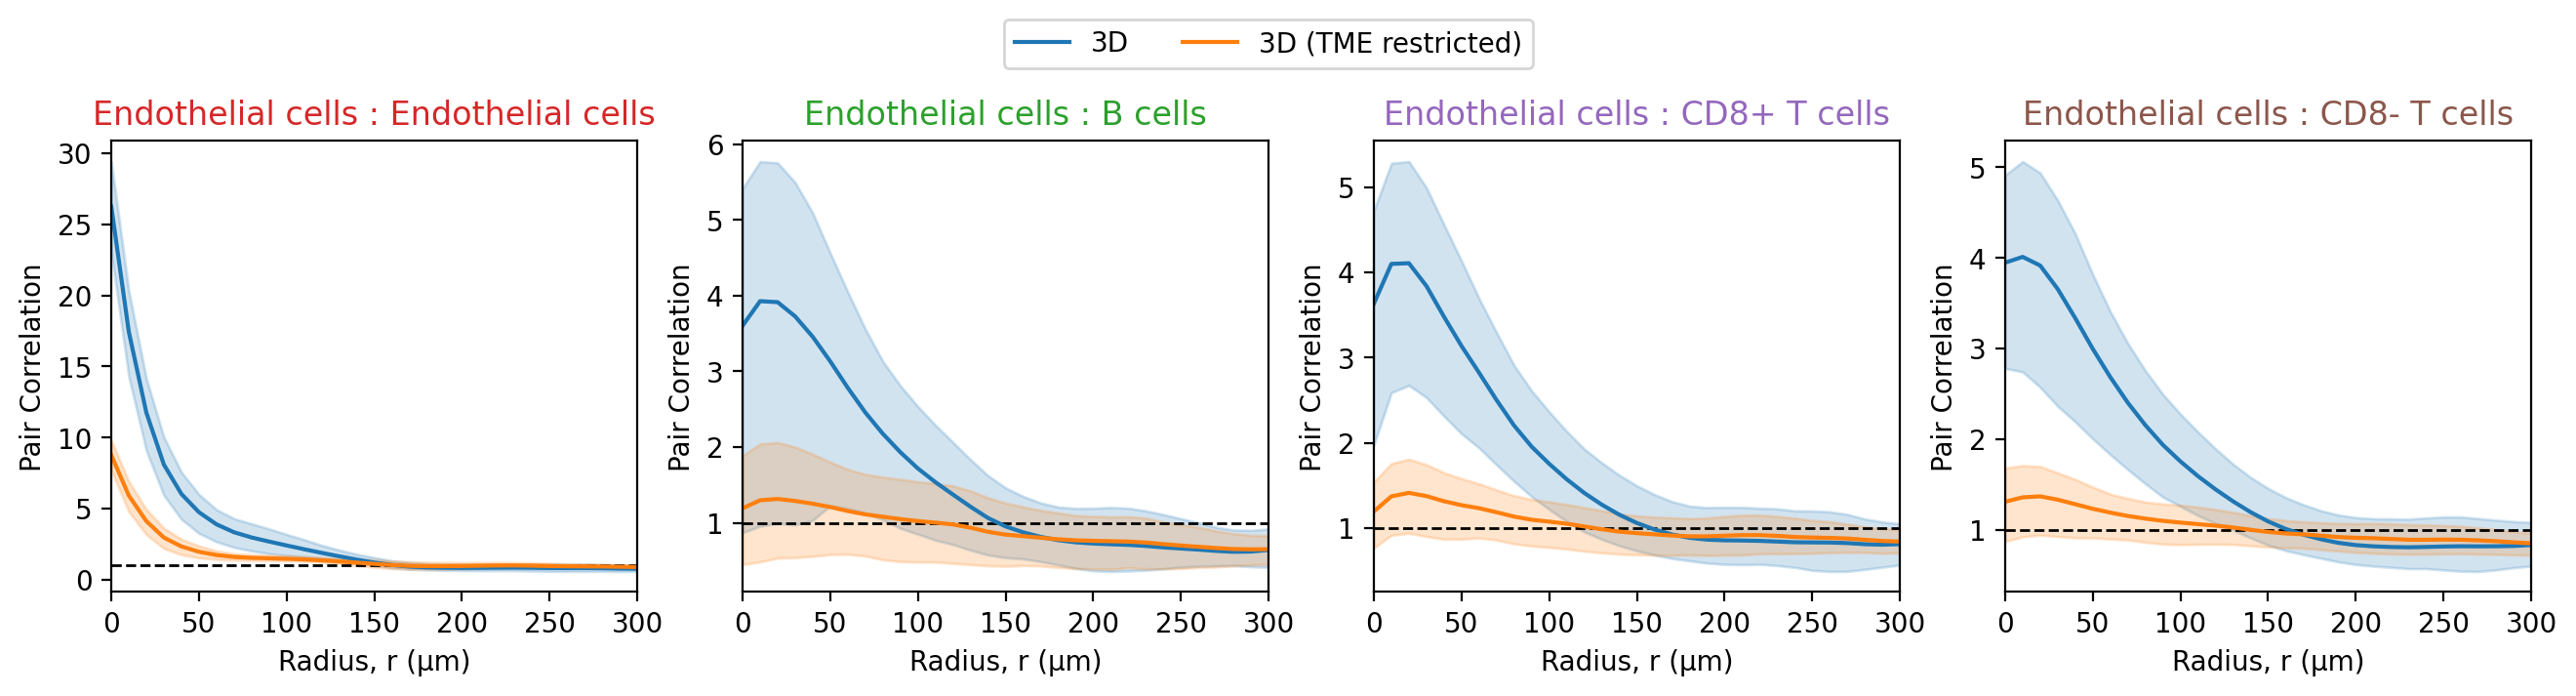

In [339]:
fig,ax=plt.subplots(1,len(pairwise_combinations),figsize=(4*len(pairwise_combinations),3))  

for idx,this_pairwise_combinations in enumerate(pairwise_combinations):
    if this_pairwise_combinations in dict_of_results_3d:
        this_r_all = dict_of_results_3d[this_pairwise_combinations]['all_3D']['r']
        this_g_all = dict_of_results_3d[this_pairwise_combinations]['all_3D']['g']
        this_CI_all = dict_of_results_3d[this_pairwise_combinations]['all_3D']['CI']   

        this_r_stromal = dict_of_results_3d[this_pairwise_combinations]['stromal_3D']['r']
        this_g_stromal = dict_of_results_3d[this_pairwise_combinations]['stromal_3D']['g']
        this_CI_stromal = dict_of_results_3d[this_pairwise_combinations]['stromal_3D']['CI']   

        ax[idx].axhline(1, linestyle='--', color='black', linewidth=1)
        ax[idx].plot(this_r_all,this_g_all,label='3D',color='tab:blue')
        ax[idx].fill_between(this_r_all, this_CI_all[0], this_CI_all[1], color='tab:blue', alpha=0.2)
        
        ax[idx].plot(this_r_stromal,this_g_stromal,label='3D (TME restricted)',color='tab:orange') 
        ax[idx].fill_between(this_r_stromal, this_CI_stromal[0], this_CI_stromal[1], color='tab:orange', alpha=0.2)  
        
        ax[idx].set_xlabel('Radius, r (µm)')  
        ax[idx].set_ylabel('Pair Correlation')
        ax[idx].set_xlim(0,netPCF_kwargs_3d['r_max']) 
        ax[idx].set_title(f'{this_pairwise_combinations[0]} : {this_pairwise_combinations[1]}', color=label_colors[this_pairwise_combinations[1]])
ax[1].legend(loc='upper center', ncol=4, bbox_to_anchor=(1, 1.3), frameon=True)
#fig.savefig(f'{path_to_save_figs}/3D_pcf_comparison.png',bbox_inches='tight',dpi=300)


# check of B-cell T-cell relationships

In [22]:
cells_of_interest = ['B cells', 'CD8+ T cells', 'CD8- T cells', 'Endothelial cells', 'Macrophages']
pairwise_combinations_TB=[('B cells','CD8+ T cells'),('B cells','CD8- T cells')]


run_3d_analysis=False
# full 3D netPCF analysis
if run_3d_analysis:

    dict_of_results_3d_TB = {}

    for this_pairwise_combination in pairwise_combinations_TB:

        dict_of_results_3d_TB[this_pairwise_combination]=dict()

        # get the nodes of interest
        cell_type_a_nodes_all = all_nodes[labels==this_pairwise_combination[0]]
        cell_type_b_nodes_all = all_nodes[labels==this_pairwise_combination[1]]

        this_r_all,this_g_all,CI_all = sn.point_patterns.cross_pair_correlation_function(G_all_3D,
                                                                nodes_a=cell_type_a_nodes_all,
                                                                nodes_b=cell_type_b_nodes_all,
                                                                **netPCF_kwargs_3d) 

        dict_of_results_3d_TB[this_pairwise_combination]['all_3D']={'r':this_r_all,'g':this_g_all,'CI':CI_all}

        # get the nodes of interest
        cell_type_a_nodes_stromal = stromal_nodes[stromal_labels==this_pairwise_combination[0]]
        cell_type_b_nodes_stromal = stromal_nodes[stromal_labels==this_pairwise_combination[1]]

        this_r_stromal,this_g_stromal,CI_stromal = sn.point_patterns.cross_pair_correlation_function(G_stromal_3D,
                                                                nodes_a=cell_type_a_nodes_stromal,
                                                                nodes_b=cell_type_b_nodes_stromal,
                                                                **netPCF_kwargs_3d) 

        dict_of_results_3d_TB[this_pairwise_combination]['stromal_3D']={'r':this_r_stromal,'g':this_g_stromal,'CI':CI_stromal}

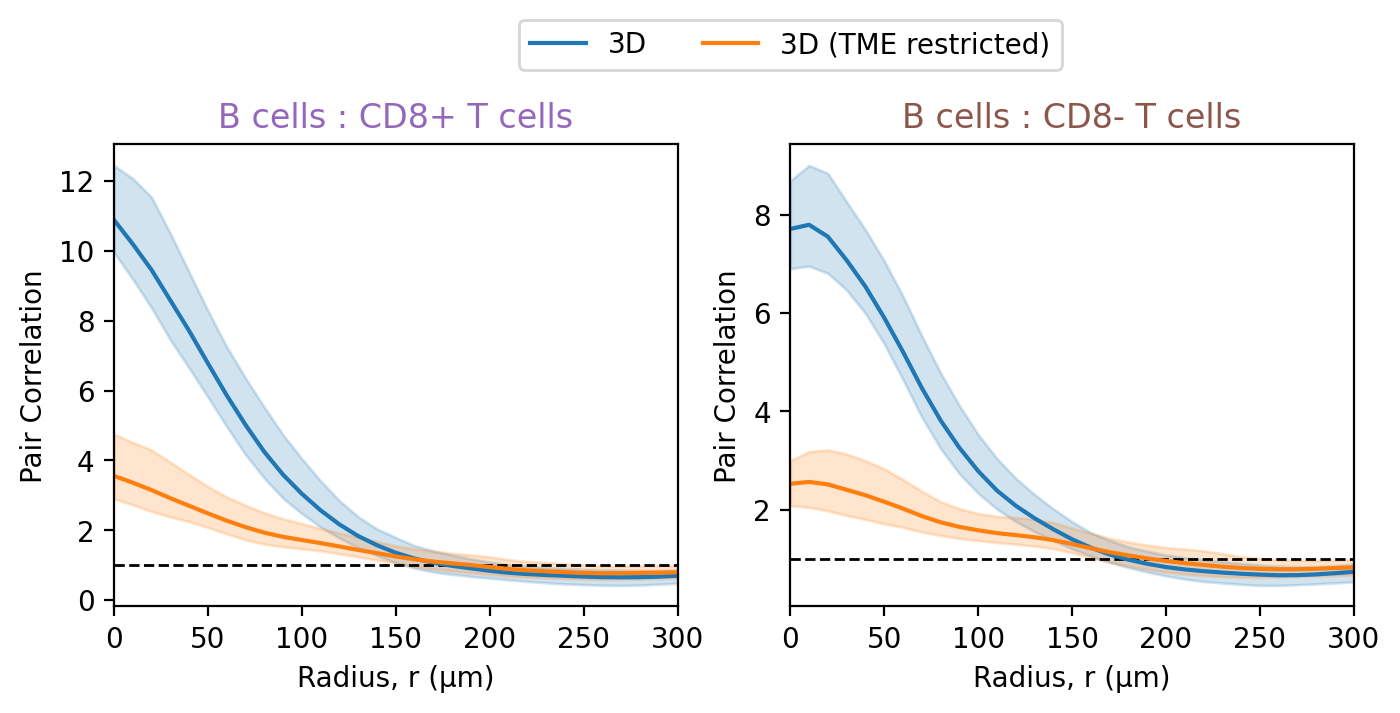

In [24]:
fig,ax=plt.subplots(1,len(pairwise_combinations_TB),figsize=(4*len(pairwise_combinations_TB),3))  

for idx,this_pairwise_combinations in enumerate(pairwise_combinations_TB):
    if this_pairwise_combinations in dict_of_results_3d_TB:
        this_r_all = dict_of_results_3d_TB[this_pairwise_combinations]['all_3D']['r']
        this_g_all = dict_of_results_3d_TB[this_pairwise_combinations]['all_3D']['g']
        this_CI_all = dict_of_results_3d_TB[this_pairwise_combinations]['all_3D']['CI']   

        this_r_stromal = dict_of_results_3d_TB[this_pairwise_combinations]['stromal_3D']['r']
        this_g_stromal = dict_of_results_3d_TB[this_pairwise_combinations]['stromal_3D']['g']
        this_CI_stromal = dict_of_results_3d_TB[this_pairwise_combinations]['stromal_3D']['CI']   

        ax[idx].axhline(1, linestyle='--', color='black', linewidth=1)
        ax[idx].plot(this_r_all,this_g_all,label='3D',color='tab:blue')
        ax[idx].fill_between(this_r_all, this_CI_all[0], this_CI_all[1], color='tab:blue', alpha=0.2)
        
        ax[idx].plot(this_r_stromal,this_g_stromal,label='3D (TME restricted)',color='tab:orange') 
        ax[idx].fill_between(this_r_stromal, this_CI_stromal[0], this_CI_stromal[1], color='tab:orange', alpha=0.2)  
        
        ax[idx].set_xlabel('Radius, r (µm)')  
        ax[idx].set_ylabel('Pair Correlation')
        #ax[idx].set_title(f'{this_pairwise_combinations[0]} : {this_pairwise_combinations[1]}')
        ax[idx].set_xlim(0,netPCF_kwargs_3d['r_max']) 
        ax[idx].set_title(f'{this_pairwise_combinations[0]} : {this_pairwise_combinations[1]}', color=label_colors[this_pairwise_combinations[1]])
ax[1].legend(loc='upper center', ncol=4, bbox_to_anchor=(0, 1.3), frameon=True)
#fig.savefig(f'{path_to_save_figs}/3D_pcf_comparison_TB.png',bbox_inches='tight',dpi=300)


# 2D analysis (ENDO)

In [11]:
dict_of_results = {}

# full 3D netPCF analysis
z_step=4
z_slices = np.arange(10, 250, z_step)
z_step = 4

for this_z in z_slices:
    # build the 2D network for this z slice
    z_distance_mask = np.logical_and(points[:,2] >= this_z, points[:,2] <= this_z+z_step)
    z_stromal_mask = np.logical_and(labels != 'Epithelial', z_distance_mask)
    
    
    this_z_points = points[z_distance_mask,:]
    this_z_labels = labels[z_distance_mask]
    
    this_z_stromal_points = points[z_stromal_mask,:]
    this_z_stromal_labels = labels[z_stromal_mask]
    
    
    G_all_2D = sn.utils.spatial_network_from_points(this_z_points,**network_kwargs)
    G_stromal_2D = sn.utils.spatial_network_from_points(this_z_stromal_points,**network_kwargs)       
    
    nodes_2D = np.array(G_all_2D.nodes())   
    stromal_nodes_2D = np.array(G_stromal_2D.nodes())    
    
    for this_pairwise_combination in pairwise_combinations:
        
        if this_pairwise_combination not in dict_of_results:
            dict_of_results[this_pairwise_combination]=dict()
        
        try:
            # get the nodes of interest
            cell_type_a_nodes_all = nodes_2D[this_z_labels==this_pairwise_combination[0]]
            cell_type_b_nodes_all = nodes_2D[this_z_labels==this_pairwise_combination[1]]

            this_r_2d_all,this_g_2d_all,CI_2d_all = sn.point_patterns.cross_pair_correlation_function(G_all_2D,
                                                                    nodes_a=cell_type_a_nodes_all,
                                                                    nodes_b=cell_type_b_nodes_all,
                                                                    **netPCF_kwargs_2d) 

            dict_of_results[this_pairwise_combination][f'all_2D_z_{this_z}']={'r':this_r_2d_all,'g':this_g_2d_all,'CI':CI_2d_all}

            # get the nodes of interest
            cell_type_a_nodes_stromal = stromal_nodes_2D[this_z_stromal_labels==this_pairwise_combination[0]]
            cell_type_b_nodes_stromal = stromal_nodes_2D[this_z_stromal_labels==this_pairwise_combination[1]]

            this_r_stromal,this_g_stromal,CI_stromal = sn.point_patterns.cross_pair_correlation_function(G_stromal_2D,
                                                                    nodes_a=cell_type_a_nodes_stromal,
                                                                    nodes_b=cell_type_b_nodes_stromal,
                                                                    **netPCF_kwargs_2d) 

            dict_of_results[this_pairwise_combination][f'stromal_2D_z_{this_z}']={'r':this_r_stromal,'g':this_g_stromal,'CI':CI_stromal}
        except Exception as e:
            print(f"Error processing pair {this_pairwise_combination} at z={this_z}: {e}")
            # remove any partial results for this pair and z slice
            if f'all_2D_z_{this_z}' in dict_of_results[this_pairwise_combination]:
                del dict_of_results[this_pairwise_combination][f'all_2D_z_{this_z}']
            if f'stromal_2D_z_{this_z}' in dict_of_results[this_pairwise_combination]:
                del dict_of_results[this_pairwise_combination][f'stromal_2D_z_{this_z}']
            



Error processing pair ('Endothelial cells', 'B cells') at z=14: The object_indices_A is empty following filteration of node check.
Error processing pair ('Endothelial cells', 'Endothelial cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('Endothelial cells', 'B cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('Endothelial cells', 'CD8+ T cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('Endothelial cells', 'CD8- T cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('Endothelial cells', 'Endothelial cell

In [ ]:
#fig,ax=plt.subplots(1,len(pairwise_combinations),figsize=(4*len(pairwise_combinations),3))  

color_map_full_z = plt.cm.Reds(np.linspace(0, 1, 291))  # Create a colormap for values between 0 and 290
colors_at_z_full = color_map_full_z[this_z]  # Get colors at the specified this_z values

color_map_stromal_z = plt.cm.Blues(np.linspace(0, 1, 291))  # Create a colormap for values between 0 and 290
colors_at_z_stromal = color_map_stromal_z[this_z]  # Get colors at the specified this_z values

for this_z_rep in z_slices:
    fig,ax=plt.subplots(1,len(pairwise_combinations),figsize=(4*len(pairwise_combinations),3))  

    for idx,this_pairwise_combinations in enumerate(pairwise_combinations):
        if this_pairwise_combinations in dict_of_results:
            for zi,this_z in enumerate([this_z_rep]):
                if f'all_2D_z_{this_z}' not in dict_of_results[this_pairwise_combinations] or f'stromal_2D_z_{this_z}' not in dict_of_results[this_pairwise_combinations]:
                    print(f"Missing data for pair {this_pairwise_combinations} at z={this_z}, skipping this slice.")
                    continue
                this_r_all = dict_of_results[this_pairwise_combinations][f'all_2D_z_{this_z}']['r']
                this_g_all = dict_of_results[this_pairwise_combinations][f'all_2D_z_{this_z}']['g']
                this_CI_all = dict_of_results[this_pairwise_combinations][f'all_2D_z_{this_z}']['CI']   

                this_r_stromal = dict_of_results[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['r']
                this_g_stromal = dict_of_results[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['g']
                this_CI_stromal = dict_of_results[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['CI']   

                ax[idx].axhline(1, linestyle='--', color='black', linewidth=1)
                ax[idx].plot(this_r_all,this_g_all,label=f'2D: z = {this_z}µm',color='tab:blue')
                ax[idx].fill_between(this_r_all, this_CI_all[0], this_CI_all[1], color='tab:blue', alpha=0.2)
                
                ax[idx].plot(this_r_stromal,this_g_stromal,label=f'2D: z = {this_z}µm (TME restricted)',color='tab:orange') 
                ax[idx].fill_between(this_r_stromal, this_CI_stromal[0], this_CI_stromal[1], color='tab:orange', alpha=0.2)  
            
            ax[idx].set_xlabel('Radius, r (µm)')  
            ax[idx].set_ylabel('Pair Correlation')
            ax[idx].set_title(f'{this_pairwise_combinations[0]} : {this_pairwise_combinations[1]}', color=label_colors[this_pairwise_combinations[1]])
            ax[idx].set_xlim(0,netPCF_kwargs_2d['r_max']) 
            #ax[idx].legend()
    ax[1].legend(loc='upper center', ncol=4, bbox_to_anchor=(1, 1.3), frameon=True)
    #fig.savefig(f'/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/case_study_bm/april_figs/check_2d/cross_pcf_z_{this_z_rep}.png', bbox_inches='tight',dpi=300)
    plt.close(fig)



# 2D analysis (TB)

In [29]:
dict_of_results_TB = {}

# full 3D netPCF analysis
z_step=4
z_slices = np.arange(10, 250, z_step)
z_step = 4

for this_z in z_slices:
    # build the 2D network for this z slice
    z_distance_mask = np.logical_and(points[:,2] >= this_z, points[:,2] <= this_z+z_step)
    z_stromal_mask = np.logical_and(labels != 'Epithelial', z_distance_mask)
    
    
    this_z_points = points[z_distance_mask,:]
    this_z_labels = labels[z_distance_mask]
    
    this_z_stromal_points = points[z_stromal_mask,:]
    this_z_stromal_labels = labels[z_stromal_mask]
    
    
    G_all_2D = sn.utils.spatial_network_from_points(this_z_points,**network_kwargs)
    G_stromal_2D = sn.utils.spatial_network_from_points(this_z_stromal_points,**network_kwargs)       
    
    nodes_2D = np.array(G_all_2D.nodes())   
    stromal_nodes_2D = np.array(G_stromal_2D.nodes())    
    
    for this_pairwise_combination in pairwise_combinations_TB:
        
        if this_pairwise_combination not in dict_of_results_TB:
            dict_of_results_TB[this_pairwise_combination]=dict()
        
        try:
            # get the nodes of interest
            cell_type_a_nodes_all = nodes_2D[this_z_labels==this_pairwise_combination[0]]
            cell_type_b_nodes_all = nodes_2D[this_z_labels==this_pairwise_combination[1]]

            this_r_2d_all,this_g_2d_all,CI_2d_all = sn.point_patterns.cross_pair_correlation_function(G_all_2D,
                                                                    nodes_a=cell_type_a_nodes_all,
                                                                    nodes_b=cell_type_b_nodes_all,
                                                                    **netPCF_kwargs_2d) 

            dict_of_results_TB[this_pairwise_combination][f'all_2D_z_{this_z}']={'r':this_r_2d_all,'g':this_g_2d_all,'CI':CI_2d_all}

            # get the nodes of interest
            cell_type_a_nodes_stromal = stromal_nodes_2D[this_z_stromal_labels==this_pairwise_combination[0]]
            cell_type_b_nodes_stromal = stromal_nodes_2D[this_z_stromal_labels==this_pairwise_combination[1]]

            this_r_stromal,this_g_stromal,CI_stromal = sn.point_patterns.cross_pair_correlation_function(G_stromal_2D,
                                                                    nodes_a=cell_type_a_nodes_stromal,
                                                                    nodes_b=cell_type_b_nodes_stromal,
                                                                    **netPCF_kwargs_2d) 

            dict_of_results_TB[this_pairwise_combination][f'stromal_2D_z_{this_z}']={'r':this_r_stromal,'g':this_g_stromal,'CI':CI_stromal}
        except Exception as e:
            print(f"Error processing pair {this_pairwise_combination} at z={this_z}: {e}")
            # remove any partial results for this pair and z slice
            if f'all_2D_z_{this_z}' in dict_of_results_TB[this_pairwise_combination]:
                del dict_of_results_TB[this_pairwise_combination][f'all_2D_z_{this_z}']
            if f'stromal_2D_z_{this_z}' in dict_of_results_TB[this_pairwise_combination]:
                del dict_of_results_TB[this_pairwise_combination][f'stromal_2D_z_{this_z}']
            



Error processing pair ('B cells', 'CD8+ T cells') at z=14: The object_indices_A is empty following filteration of node check.
Error processing pair ('B cells', 'CD8- T cells') at z=14: The object_indices_A is empty following filteration of node check.
Error processing pair ('B cells', 'CD8+ T cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('B cells', 'CD8- T cells') at z=122: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('B cells', 'CD8+ T cells') at z=158: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a connected network.
Error processing pair ('B cells', 'CD8- T cells') at z=158: After filtering to the largest connected component, less than 60% of the original nodes remain. Please provide a

Missing data for pair ('B cells', 'CD8+ T cells') at z=14, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=14, skipping this slice.


/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_89569/2929509966.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='upper center', ncol=4, bbox_to_anchor=(0, 1.3), frameon=True)


Missing data for pair ('B cells', 'CD8+ T cells') at z=122, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=122, skipping this slice.
Missing data for pair ('B cells', 'CD8+ T cells') at z=158, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=158, skipping this slice.
Missing data for pair ('B cells', 'CD8+ T cells') at z=162, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=162, skipping this slice.
Missing data for pair ('B cells', 'CD8+ T cells') at z=166, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=166, skipping this slice.
Missing data for pair ('B cells', 'CD8+ T cells') at z=170, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=170, skipping this slice.
Missing data for pair ('B cells', 'CD8+ T cells') at z=174, skipping this slice.
Missing data for pair ('B cells', 'CD8- T cells') at z=174, skipping this slice.
Missing data for pair ('B ce

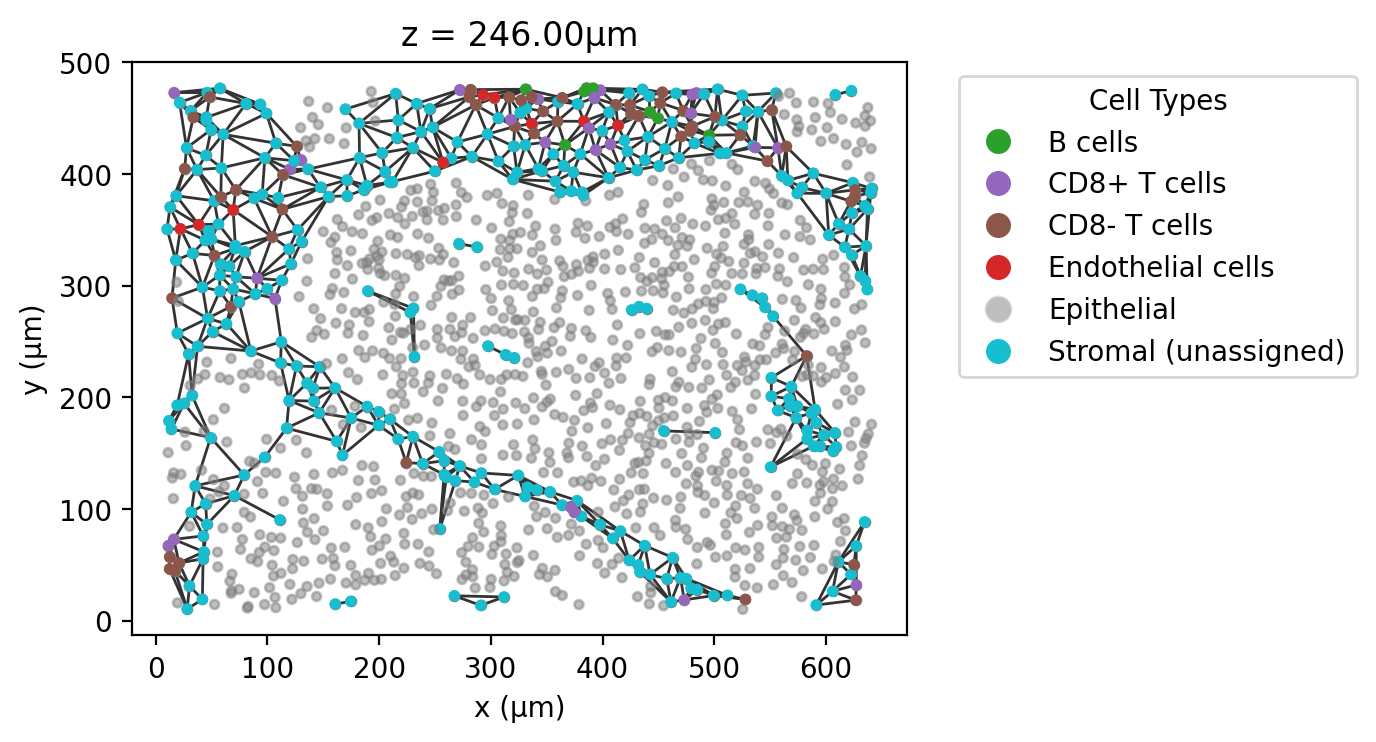

In [31]:
#fig,ax=plt.subplots(1,len(pairwise_combinations),figsize=(4*len(pairwise_combinations),3))  

color_map_full_z = plt.cm.Reds(np.linspace(0, 1, 291))  # Create a colormap for values between 0 and 290
colors_at_z_full = color_map_full_z[this_z]  # Get colors at the specified this_z values

color_map_stromal_z = plt.cm.Blues(np.linspace(0, 1, 291))  # Create a colormap for values between 0 and 290
colors_at_z_stromal = color_map_stromal_z[this_z]  # Get colors at the specified this_z values

for this_z_rep in z_slices:
    fig,ax=plt.subplots(1,len(pairwise_combinations_TB),figsize=(4*len(pairwise_combinations_TB),3))  

    for idx,this_pairwise_combinations in enumerate(pairwise_combinations_TB):
        if this_pairwise_combinations in dict_of_results_TB:
            for zi,this_z in enumerate([this_z_rep]):
                if f'all_2D_z_{this_z}' not in dict_of_results_TB[this_pairwise_combinations] or f'stromal_2D_z_{this_z}' not in dict_of_results_TB[this_pairwise_combinations]:
                    print(f"Missing data for pair {this_pairwise_combinations} at z={this_z}, skipping this slice.")
                    continue
                this_r_all = dict_of_results_TB[this_pairwise_combinations][f'all_2D_z_{this_z}']['r']
                this_g_all = dict_of_results_TB[this_pairwise_combinations][f'all_2D_z_{this_z}']['g']
                this_CI_all = dict_of_results_TB[this_pairwise_combinations][f'all_2D_z_{this_z}']['CI']   

                this_r_stromal = dict_of_results_TB[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['r']
                this_g_stromal = dict_of_results_TB[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['g']
                this_CI_stromal = dict_of_results_TB[this_pairwise_combinations][f'stromal_2D_z_{this_z}']['CI']   

                ax[idx].axhline(1, linestyle='--', color='black', linewidth=1)
                ax[idx].plot(this_r_all,this_g_all,label=f'2D: z = {this_z}µm',color='tab:blue')
                ax[idx].fill_between(this_r_all, this_CI_all[0], this_CI_all[1], color='tab:blue', alpha=0.2)
                
                ax[idx].plot(this_r_stromal,this_g_stromal,label=f'2D: z = {this_z}µm (TME restricted)',color='tab:orange') 
                ax[idx].fill_between(this_r_stromal, this_CI_stromal[0], this_CI_stromal[1], color='tab:orange', alpha=0.2)  
            
            ax[idx].set_xlabel('Radius, r (µm)')  
            ax[idx].set_ylabel('Pair Correlation')
            ax[idx].set_title(f'{this_pairwise_combinations[0]} : {this_pairwise_combinations[1]}', color=label_colors[this_pairwise_combinations[1]])
            ax[idx].set_xlim(0,netPCF_kwargs_2d['r_max']) 
            #ax[idx].legend()
    ax[1].legend(loc='upper center', ncol=4, bbox_to_anchor=(0, 1.3), frameon=True)
    #fig.savefig(f'/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/case_study_bm/april_figs/check_2d_TB/cross_pcf_z_{this_z_rep}.png', bbox_inches='tight',dpi=300)
    plt.close(fig)